# Travel Reimbursement Approval Agent


### What this notebook demonstrates
- Structured claim intake from Python dictionaries/JSON-like records.
- Policy grounding using stable `POL-*` references.
- Multiple meaningful tools:
  1. `policy_lookup`
  2. `receipt_completeness_check`
  3. `limit_checker`
  4. `approval_threshold_check`
  5. `timeliness_check`
  6. `output_validator`
- An agentic workflow that decides which checks are required, executes tools, combines their results, and routes ambiguous/exception cases to `MANUAL_REVIEW`.
- Deterministic policy enforcement for business-critical amounts, with an optional LLM layer for tool-selection/reasoning/explanation.
- A data-driven dashboard and a final JSON array containing exactly the required fields.


## Optional: Run with Groq LLM / Agentic Flow

The core reimbursement evaluation is deterministic and can be run without an LLM.

**You can skip this cell if you only want to run the deterministic policy evaluation.**



In [1]:
# Optional Groq LLM / Agentic AI setup
import os
from getpass import getpass

# Enable Groq for the agentic flow
os.environ["USE_GROQ"] = "1"

# Read the key from the environment, or securely prompt for it.
if not os.getenv("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass(
        "Enter your Groq API key (input will be hidden): "
    )

print("Groq API key configured:", bool(os.getenv("GROQ_API_KEY")))
print("Groq agentic flow enabled:", os.getenv("USE_GROQ") != "0")


Groq API key configured: True
Groq agentic flow enabled: True


## README — Setup & Run

### Runtime
Python 3.x recommended.

### Dependencies
The prototype uses `pandas` and `matplotlib` for the dashboard and the `openai` Python client configured against Groq's OpenAI-compatible endpoint for the GenAI/tool-calling planner.


### Groq configuration
This notebook uses **Groq as the LLM provider through the OpenAI Python client**. The client is configured with Groq's OpenAI-compatible base URL: `https://api.groq.com/openai/v1`.

Set the API key as an environment variable **before running the notebook**:


Optional:
- `GROQ_MODEL` — defaults to `openai/gpt-oss-120b`
- `USE_GROQ` — set to `0` to force deterministic fallback mode

The notebook automatically falls back to the deterministic planner if `GROQ_API_KEY` is unavailable or the SDK/API call fails.

### Agent architecture
The Groq-backed OpenAI client is used as the **agentic planner**. It receives the claim and tool schemas, chooses relevant tools, the notebook executes those tools, and their results are returned to the model for the next tool decision. Policy-critical arithmetic and final approval gates remain deterministic and are independently validated.

### Run
Run all cells top-to-bottom.



## 1. Policy Grounding

The following policy rules are transcribed from Appendix A of the assignment.

| Rule | Policy |
|---|---|
| POL-CAT-01 | Airfare (economy), lodging, meals, ground transport, conference/registration fees are eligible when incurred for documented business purpose. |
| POL-CAT-02 | Alcohol/minibar, spa/gym/entertainment, personal shopping/gifts, fines/penalties/late fees, and personal expenses are ineligible. |
| POL-PD-01 | Meals: maximum $75 per day. Excess is deducted. |
| POL-PD-02 | Lodging: maximum $200 per night. Excess is deducted. |
| POL-PD-03 | Ground transport: maximum $50 per day. Excess is deducted. |
| POL-AIR-01 | Only economy airfare is reimbursable. Business/first class is a policy exception and goes to Manual Review. |
| POL-RCT-01 | Receipt required above $25; airfare and lodging always require a receipt. |
| POL-RCT-02 | Missing required receipt → Manual Review. |
| POL-APR-01 | Total reimbursable amount ≤ $500 may be auto-approved if fully compliant. |
| POL-APR-02 | $500 < total reimbursable amount ≤ $2,000 is approvable when fully compliant. |
| POL-APR-03 | Total reimbursable amount > $2,000 → Manual Review/director approval. |
| POL-TIME-01 | Claim must be submitted within 30 days of the expense date; late claim → Manual Review. |


In [2]:
from __future__ import annotations

import json
import os
from dataclasses import dataclass
from datetime import date, datetime
from typing import Any, Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt

print("Environment ready.")


Environment ready.


## 2. Claim Intake

The five claims below are the exact sample claims from Appendix B. No additional claim set is invented.


In [3]:
claims = [
    {
        "claim_id": "CLM-001",
        "employee": "A. Rivera",
        "trip_start": "2026-06-10",
        "trip_end": "2026-06-12",
        "submitted": "2026-06-20",
        "business_purpose": "Attend 2-day industry conference (business)",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt_attached": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt_attached": True, "nights": 2},
            {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt_attached": True, "days": 3},
            {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt_attached": True},
        ],
    },
    {
        "claim_id": "CLM-002",
        "employee": "B. Osei",
        "trip_start": "2026-06-14",
        "trip_end": "2026-06-15",
        "submitted": "2026-06-25",
        "business_purpose": "Weekend hotel stay",
        "items": [
            {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt_attached": True},
            {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt_attached": True},
        ],
    },
    {
        "claim_id": "CLM-003",
        "employee": "C. Nakamura",
        "trip_start": "2026-06-08",
        "trip_end": "2026-06-10",
        "submitted": "2026-06-22",
        "business_purpose": "Client site visit (business)",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt_attached": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt_attached": True, "nights": 2},
            {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt_attached": True, "days": 2},
        ],
    },
    {
        "claim_id": "CLM-004",
        "employee": "D. Fischer",
        "trip_start": "2026-06-16",
        "trip_end": "2026-06-18",
        "submitted": "2026-06-28",
        "business_purpose": "International vendor negotiation (business)",
        "items": [
            {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt_attached": True},
            {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt_attached": False, "nights": 3},
        ],
    },
    {
        "claim_id": "CLM-005",
        "employee": "E. Haddad",
        "trip_start": "2026-06-11",
        "trip_end": "2026-06-11",
        "submitted": "2026-06-24",
        "business_purpose": "Client dinner / business development",
        "items": [
            {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt_attached": False, "days": 1},
        ],
    },
]

claims_df = pd.DataFrame([
    {
        "claim_id": c["claim_id"],
        "employee": c["employee"],
        "claimed_amount": sum(i["amount"] for i in c["items"]),
        "items": len(c["items"]),
    }
    for c in claims
])
claims_df


,claim_id,employee,claimed_amount,items
0,CLM-001,A. Rivera,1110.0,4
1,CLM-002,B. Osei,380.0,2
2,CLM-003,C. Nakamura,940.0,3
3,CLM-004,D. Fischer,3000.0,2
4,CLM-005,E. Haddad,220.0,1


## 3. Policy Knowledge Base

A small structured policy store makes retrieval explicit and auditable. `policy_lookup()` returns only the rules relevant to the claim/item being evaluated.


In [4]:
POLICY = {
    "POL-CAT-01": {
        "text": "Eligible: economy airfare, lodging, meals, ground transport, conference/registration fees when incurred for documented business purpose.",
        "type": "eligibility",
    },
    "POL-CAT-02": {
        "text": "Ineligible: alcohol/minibar, spa/gym/personal entertainment, in-room movies, personal shopping/gifts, traffic fines/penalties/late fees, and personal non-business expenses.",
        "type": "eligibility",
    },
    "POL-PD-01": {
        "text": "Meals maximum $75 per day; excess is deducted.",
        "type": "limit",
        "category": "meals",
        "limit": 75.0,
        "unit": "day",
    },
    "POL-PD-02": {
        "text": "Lodging maximum $200 per night; excess is deducted.",
        "type": "limit",
        "category": "lodging",
        "limit": 200.0,
        "unit": "night",
    },
    "POL-PD-03": {
        "text": "Ground transport maximum $50 per day; excess is deducted.",
        "type": "limit",
        "category": "ground_transport",
        "limit": 50.0,
        "unit": "day",
    },
    "POL-AIR-01": {
        "text": "Only economy airfare is reimbursable. Business/first class is a policy exception and must be routed to Manual Review.",
        "type": "exception",
    },
    "POL-RCT-01": {
        "text": "Receipt required above $25. Airfare and lodging always require a receipt.",
        "type": "receipt",
    },
    "POL-RCT-02": {
        "text": "Missing required receipt routes the claim to Manual Review.",
        "type": "receipt",
    },
    "POL-APR-01": {
        "text": "Total reimbursable amount <= $500 may be auto-approved if fully compliant.",
        "type": "approval",
        "max": 500.0,
    },
    "POL-APR-02": {
        "text": "Total reimbursable amount > $500 and <= $2,000 is approvable when fully compliant.",
        "type": "approval",
        "max": 2000.0,
    },
    "POL-APR-03": {
        "text": "Total reimbursable amount > $2,000 exceeds agent authority and must be routed to Manual Review.",
        "type": "approval",
        "min_exclusive": 2000.0,
    },
    "POL-TIME-01": {
        "text": "Claims must be submitted within 30 days of the expense date; late claims route to Manual Review.",
        "type": "timeliness",
        "days": 30,
    },
}

CATEGORY_POLICY_REFS = {
    "airfare": ["POL-CAT-01", "POL-AIR-01"],
    "lodging": ["POL-CAT-01", "POL-PD-02"],
    "meals": ["POL-CAT-01", "POL-PD-01"],
    "ground_transport": ["POL-CAT-01", "POL-PD-03"],
    "conference_fees": ["POL-CAT-01"],
    "spa": ["POL-CAT-02"],
    "minibar": ["POL-CAT-02"],
}

def policy_lookup(category: str | None = None, purpose: str | None = None, needs: List[str] | None = None) -> Dict[str, Any]:
    """Retrieve relevant policy context by category/check type."""
    refs = []
    if category in CATEGORY_POLICY_REFS:
        refs.extend(CATEGORY_POLICY_REFS[category])
    if category in {"spa", "minibar"}:
        refs.append("POL-CAT-02")
    if needs:
        for need in needs:
            if need == "receipt":
                refs.extend(["POL-RCT-01", "POL-RCT-02"])
            elif need == "approval":
                refs.extend(["POL-APR-01", "POL-APR-02", "POL-APR-03"])
            elif need == "timeliness":
                refs.append("POL-TIME-01")
    # Preserve order and remove duplicates.
    refs = list(dict.fromkeys(refs))
    return {ref: POLICY[ref] for ref in refs}

print("Policy rules loaded:", len(POLICY))


Policy rules loaded: 12


## 4. Agent Tools

The agent uses separate tools for separate responsibilities. This keeps calculations deterministic and makes the audit trail easy to inspect.


In [5]:
ELIGIBLE_CATEGORIES = {"airfare", "lodging", "meals", "ground_transport", "conference_fees"}
INELIGIBLE_CATEGORIES = {"alcohol", "minibar", "spa", "gym", "personal_entertainment", "in_room_movies", "personal_shopping", "gifts", "traffic_fine", "penalty", "late_fee"}

def receipt_completeness_check(claim: Dict[str, Any]) -> Dict[str, Any]:
    """Check receipt requirements using POL-RCT-01 and route missing required receipts to review."""
    missing = []
    checks = []
    for item in claim["items"]:
        required = item["category"] in {"airfare", "lodging"} or item["amount"] > 25
        if required and not item.get("receipt_attached", False):
            missing.append({
                "category": item["category"],
                "amount": item["amount"],
                "reason": "Required receipt missing",
            })
        checks.append({
            "category": item["category"],
            "receipt_required": required,
            "receipt_attached": bool(item.get("receipt_attached", False)),
        })
    return {
        "tool": "receipt_completeness_check",
        "passed": len(missing) == 0,
        "missing_receipts": missing,
        "policy_refs": ["POL-RCT-01", "POL-RCT-02"],
        "checks": checks,
    }

def limit_checker(claim: Dict[str, Any]) -> Dict[str, Any]:
    """Apply category limits. Returns allowed and deducted amounts per item."""
    details = []
    approved = 0.0
    deducted = 0.0
    exceptions = []

    for item in claim["items"]:
        category = item["category"]
        amount = float(item["amount"])
        allowed = amount
        cap = None
        basis = None
        refs = []

        if category == "meals":
            days = item.get("days", 1)
            cap = 75.0 * days
            basis = f"$75/day x {days} day(s)"
            refs = ["POL-PD-01"]
        elif category == "lodging":
            nights = item.get("nights", 1)
            cap = 200.0 * nights
            basis = f"$200/night x {nights} night(s)"
            refs = ["POL-PD-02"]
        elif category == "ground_transport":
            days = item.get("days", 1)
            cap = 50.0 * days
            basis = f"$50/day x {days} day(s)"
            refs = ["POL-PD-03"]

        if cap is not None and amount > cap:
            allowed = cap
        approved += max(0.0, allowed)
        deducted += max(0.0, amount - allowed)

        details.append({
            "category": category,
            "claimed": amount,
            "allowed": round(allowed, 2),
            "deducted": round(max(0.0, amount - allowed), 2),
            "cap": cap,
            "basis": basis,
            "policy_refs": refs,
        })

        # Business/first class is not auto-deducted.
        if category == "airfare" and "business-class" in item["description"].lower():
            exceptions.append({
                "category": "airfare",
                "reason": "Business/first-class airfare is a policy exception requiring Manual Review.",
                "policy_ref": "POL-AIR-01",
            })

    return {
        "tool": "limit_checker",
        "approved_before_manual_exceptions": round(approved, 2),
        "deducted_by_caps": round(deducted, 2),
        "details": details,
        "exceptions": exceptions,
        "policy_refs": ["POL-PD-01", "POL-PD-02", "POL-PD-03", "POL-AIR-01"],
    }

def approval_threshold_check(reimbursable_amount: float) -> Dict[str, Any]:
    """Check approval authority after per-diem deductions."""
    amount = float(reimbursable_amount)
    if amount <= 500:
        tier = "AUTO_APPROVE"
        refs = ["POL-APR-01"]
        manual_required = False
    elif amount <= 2000:
        tier = "MANAGER"
        refs = ["POL-APR-02"]
        manual_required = False
    else:
        tier = "DIRECTOR_MANUAL_REVIEW"
        refs = ["POL-APR-03"]
        manual_required = True
    return {
        "tool": "approval_threshold_check",
        "reimbursable_amount": round(amount, 2),
        "tier": tier,
        "manual_required": manual_required,
        "policy_refs": refs,
    }

def timeliness_check(claim: Dict[str, Any]) -> Dict[str, Any]:
    """Check the 30-day submission window."""
    # The assignment gives trip start/end and submission dates but no separate
    # expense date per line item. Use the latest trip date as the claim expense date.
    expense_date = date.fromisoformat(claim["trip_end"])
    submitted = date.fromisoformat(claim["submitted"])
    age_days = (submitted - expense_date).days
    passed = age_days <= 30
    return {
        "tool": "timeliness_check",
        "passed": passed,
        "days_after_latest_expense": age_days,
        "policy_refs": ["POL-TIME-01"],
    }

def output_validator(result: Dict[str, Any]) -> Dict[str, Any]:
    """Validate the exact final schema and basic numeric/decision constraints."""
    required = [
        "claim_id", "decision", "approved_amount", "deducted_amount",
        "missing_docs", "policy_refs", "confidence", "explanation", "tools_used"
    ]
    allowed_decisions = {"APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"}
    missing = [k for k in required if k not in result]
    errors = []
    if missing:
        errors.append(f"Missing fields: {missing}")
    if result.get("decision") not in allowed_decisions:
        errors.append("Invalid decision.")
    for k in ("approved_amount", "deducted_amount", "confidence"):
        if not isinstance(result.get(k), (int, float)):
            errors.append(f"{k} must be numeric.")
    if result.get("approved_amount", -1) < 0 or result.get("deducted_amount", -1) < 0:
        errors.append("Amounts cannot be negative.")
    if not isinstance(result.get("missing_docs"), list) or not isinstance(result.get("policy_refs"), list):
        errors.append("missing_docs and policy_refs must be lists.")
    return {"valid": len(errors) == 0, "errors": errors}

print("Tools defined.")


Tools defined.


## 5. Agentic Workflow

The workflow uses **Groq tool calling** for the agentic planning layer while keeping reimbursement calculations deterministic:

1. **Intake** the claim.
2. **Expose tool schemas** to the Groq model.
3. **Let the model select tools** based on the claim and policy context.
4. **Execute selected tools** in Python and return tool results to Groq.
5. **Repeat tool selection** for dependent checks, such as approval threshold after reimbursement calculation.
6. **Run deterministic safety checks** for every claim regardless of LLM behavior.
7. **Route exceptions** to Manual Review instead of forcing an automated decision.
8. **Validate the exact required JSON schema**.

This is deliberately a hybrid design: GenAI provides tool-selection/orchestration, while policy arithmetic and final safety gates are deterministic.


In [6]:
# Groq tool-calling agent
GROQ_MODEL = os.getenv("GROQ_MODEL", "openai/gpt-oss-120b")
USE_GROQ = os.getenv("USE_GROQ", "1") != "0"

GROQ_TOOL_SCHEMAS = [
    {
        "type": "function",
        "function": {
            "name": "policy_lookup",
            "description": "Retrieve policy rules relevant to a claim category or check.",
            "parameters": {
                "type": "object",
                "properties": {
                    "category": {"type": "string"},
                    "needs": {"type": "array", "items": {"type": "string"}},
                },
                "required": ["category", "needs"],
                "additionalProperties": False,
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "receipt_completeness_check",
            "description": "Check whether required receipts are attached for a claim. Use the claim_id provided.",
            "parameters": {
                "type": "object",
                "properties": {"claim_id": {"type": "string"}},
                "required": ["claim_id"],
                "additionalProperties": False,
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "limit_checker",
            "description": "Calculate category/per-diem limits and detect airfare class exceptions for a claim.",
            "parameters": {
                "type": "object",
                "properties": {"claim_id": {"type": "string"}},
                "required": ["claim_id"],
                "additionalProperties": False,
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "approval_threshold_check",
            "description": "Check whether a reimbursable amount is within the agent approval authority.",
            "parameters": {
                "type": "object",
                "properties": {"reimbursable_amount": {"type": "number"}},
                "required": ["reimbursable_amount"],
                "additionalProperties": False,
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "timeliness_check",
            "description": "Check whether a claim was submitted within the 30-day policy window.",
            "parameters": {
                "type": "object",
                "properties": {"claim_id": {"type": "string"}},
                "required": ["claim_id"],
                "additionalProperties": False,
            },
        },
    },
]

class TravelReimbursementAgent:
    def __init__(self, use_llm: bool = True):
        self.use_llm = use_llm and USE_GROQ
        self.llm = None
        self.groq_tool_calls = []
        if self.use_llm:
            self._try_init_llm()

    def _try_init_llm(self):
        """Initialize the OpenAI client against Groq's OpenAI-compatible endpoint."""
        api_key = os.getenv("GROQ_API_KEY")
        if not api_key:
            self.use_llm = False
            return
        try:
            from openai import OpenAI
            self.llm = OpenAI(
                api_key=api_key,
                base_url="https://api.groq.com/openai/v1",
            )
        except Exception as exc:
            print(f"Groq SDK unavailable; using deterministic fallback: {exc}")
            self.use_llm = False

    def _execute_groq_tool(self, name: str, arguments: Dict[str, Any], claim: Dict[str, Any]) -> Dict[str, Any]:
        """Execute an allow-listed local tool requested by Groq."""
        claim_index = {c["claim_id"]: c for c in claims}
        if name == "policy_lookup":
            return policy_lookup(
                category=arguments.get("category") or None,
                needs=arguments.get("needs") or [],
            )
        if name == "receipt_completeness_check":
            target = claim_index.get(arguments.get("claim_id"), claim)
            return receipt_completeness_check(target)
        if name == "limit_checker":
            target = claim_index.get(arguments.get("claim_id"), claim)
            return limit_checker(target)
        if name == "approval_threshold_check":
            return approval_threshold_check(float(arguments["reimbursable_amount"]))
        if name == "timeliness_check":
            target = claim_index.get(arguments.get("claim_id"), claim)
            return timeliness_check(target)
        raise ValueError(f"Tool not allow-listed: {name}")

    def _groq_plan_tools(self, claim: Dict[str, Any]) -> Tuple[List[str], List[Dict[str, Any]]]:
        """Run a real Groq tool-calling loop and return selected tools plus an audit trail."""
        system = (
            "You are a travel reimbursement approval agent. Select tools needed to evaluate the claim. "
            "Prefer policy lookup, receipt checks, limit checks, and timeliness checks. "
            "Use approval_threshold_check after you have a reimbursable amount. "
            "Do not invent policy rules. You do not make the final approval decision; the deterministic policy engine does that."
        )
        user = (
            "Evaluate this claim using the available tools. Retrieve relevant policy context and perform the "
            "checks needed to identify compliance, deductions, exceptions, receipts, and approval authority.\n\n"
            + json.dumps(claim, indent=2)
        )
        messages = [
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ]
        selected = []
        audit = []

        for _ in range(6):
            response = self.llm.chat.completions.create(
                model=GROQ_MODEL,
                messages=messages,
                tools=GROQ_TOOL_SCHEMAS,
                tool_choice="auto",
                temperature=0,
                max_tokens=800,
            )
            message = response.choices[0].message
            tool_calls = getattr(message, "tool_calls", None) or []

            assistant_message = {"role": "assistant", "content": message.content or ""}
            if tool_calls:
                assistant_message["tool_calls"] = [
                    {
                        "id": tc.id,
                        "type": "function",
                        "function": {
                            "name": tc.function.name,
                            "arguments": tc.function.arguments,
                        },
                    }
                    for tc in tool_calls
                ]
            messages.append(assistant_message)

            if not tool_calls:
                break

            for tc in tool_calls:
                name = tc.function.name
                try:
                    arguments = json.loads(tc.function.arguments or "{}")
                    result = self._execute_groq_tool(name, arguments, claim)
                    selected.append(name)
                    audit.append({
                        "tool": name,
                        "arguments": arguments,
                        "status": "success",
                    })
                    messages.append({
                        "role": "tool",
                        "tool_call_id": tc.id,
                        "content": json.dumps(result, default=str),
                    })
                except Exception as exc:
                    audit.append({
                        "tool": name,
                        "status": "error",
                        "error": str(exc),
                    })
                    messages.append({
                        "role": "tool",
                        "tool_call_id": tc.id,
                        "content": json.dumps({"error": str(exc)}),
                    })

        return list(dict.fromkeys(selected)), audit

    def plan_tools(self, claim: Dict[str, Any]) -> List[str]:
        """Use Groq to select tools; retain a complete deterministic safety set."""
        self.groq_tool_calls = []
        if self.use_llm and self.llm:
            try:
                selected, audit = self._groq_plan_tools(claim)
                self.groq_tool_calls = audit
                if selected:
                    return selected
            except Exception as exc:
                self.groq_tool_calls = [
                    {
                        "status": "planner_error",
                        "error": str(exc),
                        "error_type": type(exc).__name__,
                    }
                ]

                print(f"\nGroq planner failed for {claim['claim_id']}")
                print("Error type:", type(exc).__name__)
                print("Error:", str(exc))
                print("Using deterministic fallback.\n")

        return [
            "policy_lookup",
            "receipt_completeness_check",
            "limit_checker",
            "timeliness_check",
            "approval_threshold_check",
        ]

    def _policy_refs_for_claim(self, claim, receipt_result, limit_result, threshold_result, time_result):
        refs = []
        for item in claim["items"]:
            refs.extend(policy_lookup(category=item["category"]).keys())
        refs.extend(receipt_result["policy_refs"])
        refs.extend(limit_result["policy_refs"])
        refs.extend(threshold_result["policy_refs"])
        refs.extend(time_result["policy_refs"])
        return list(dict.fromkeys(refs))

    def _explanation(self, claim, decision, approved, deducted, receipt_result, limit_result, threshold_result, time_result):
        if decision == "APPROVE":
            return (
                f"All claimed items are eligible, required receipts are present, "
                f"no per-diem excess was detected, the claim is timely, and the "
                f"reimbursable amount of ${approved:.2f} is within an approvable tier "
                f"({threshold_result['tier']})."
            )
        if decision == "PARTIAL_APPROVE":
            capped = [d for d in limit_result["details"] if d["deducted"] > 0]
            cap_text = ", ".join(
                f"{d['category']} deducted ${d['deducted']:.2f}" for d in capped
            )
            return (
                f"The claim is otherwise compliant, but policy caps require deductions: "
                f"{cap_text}. Approved amount is ${approved:.2f} and deducted amount is "
                f"${deducted:.2f}."
            )
        if decision == "REJECT":
            ineligible = [
                i for i in claim["items"] if i["category"] in INELIGIBLE_CATEGORIES
            ]
            total = sum(i["amount"] for i in ineligible)
            cats = ", ".join(i["category"] for i in ineligible)
            return (
                f"All claimed items are ineligible under POL-CAT-02 ({cats}). "
                f"Nothing is reimbursable, so ${total:.2f} is deducted."
            )
        reasons = []
        if receipt_result["missing_receipts"]:
            reasons.append("required receipt(s) are missing")
        if limit_result["exceptions"]:
            reasons.append("business/first-class airfare is a policy exception")
        if threshold_result["manual_required"]:
            reasons.append("reimbursable amount exceeds the agent's approval authority")
        if not time_result["passed"]:
            reasons.append("claim is outside the 30-day submission window")
        reason_text = "; ".join(reasons) if reasons else "policy information requires human review"
        return (
            f"Manual Review is required because {reason_text}. "
            f"No final reimbursement amount is recorded until the reviewer resolves the exception."
        )

    def evaluate_claim(self, claim: Dict[str, Any]) -> Dict[str, Any]:
        selected_tools = self.plan_tools(claim)

        retrieved_context = {
            item["category"]: policy_lookup(category=item["category"])
            for item in claim["items"]
        }

        receipt_result = receipt_completeness_check(claim)
        limit_result = limit_checker(claim)
        provisional_approved = limit_result["approved_before_manual_exceptions"]

        ineligible_amount = sum(
            float(i["amount"]) for i in claim["items"]
            if i["category"] in INELIGIBLE_CATEGORIES
        )
        provisional_approved = max(0.0, provisional_approved - ineligible_amount)

        threshold_result = approval_threshold_check(provisional_approved)
        time_result = timeliness_check(claim)

        has_ineligible = any(i["category"] in INELIGIBLE_CATEGORIES for i in claim["items"])
        all_ineligible = all(i["category"] in INELIGIBLE_CATEGORIES for i in claim["items"])
        has_partial_cap = limit_result["deducted_by_caps"] > 0
        has_exception = bool(limit_result["exceptions"])
        has_manual_reason = (
            receipt_result["missing_receipts"]
            or has_exception
            or threshold_result["manual_required"]
            or not time_result["passed"]
        )

        claimed_total = sum(float(i["amount"]) for i in claim["items"])

        if has_manual_reason:
            decision = "MANUAL_REVIEW"
            approved_amount = 0.0
            deducted_amount = 0.0
            confidence = 0.98
        elif all_ineligible:
            decision = "REJECT"
            approved_amount = 0.0
            deducted_amount = claimed_total
            confidence = 0.99
        elif has_partial_cap:
            decision = "PARTIAL_APPROVE"
            approved_amount = provisional_approved
            deducted_amount = claimed_total - approved_amount
            confidence = 0.99
        elif has_ineligible:
            decision = "PARTIAL_APPROVE"
            approved_amount = provisional_approved
            deducted_amount = claimed_total - approved_amount
            confidence = 0.99
        else:
            decision = "APPROVE"
            approved_amount = provisional_approved
            deducted_amount = claimed_total - approved_amount
            confidence = 0.99

        refs = self._policy_refs_for_claim(
            claim, receipt_result, limit_result, threshold_result, time_result
        )
        explanation = self._explanation(
            claim, decision, approved_amount, deducted_amount,
            receipt_result, limit_result, threshold_result, time_result
        )

        # tools_used reports the actual policy tools executed by the workflow. The audit trail separately records
        # which of these tools Groq requested during its agentic planning loop.
        safety_tools = [
            "policy_lookup",
            "receipt_completeness_check",
            "limit_checker",
            "approval_threshold_check",
            "timeliness_check",
        ]
        tools_used = list(dict.fromkeys(selected_tools + safety_tools))

        result = {
            "claim_id": claim["claim_id"],
            "decision": decision,
            "approved_amount": round(approved_amount, 2),
            "deducted_amount": round(deducted_amount, 2),
            "missing_docs": [f"{m['category']} receipt" for m in receipt_result["missing_receipts"]],
            "policy_refs": refs,
            "confidence": confidence,
            "explanation": explanation,
            "tools_used": tools_used,
        }

        validation = output_validator(result)
        if not validation["valid"]:
            raise ValueError(f"Output validation failed for {claim['claim_id']}: {validation['errors']}")

        return {
            "result": result,
            "audit": {
                "groq_enabled": self.use_llm,
                "groq_model": GROQ_MODEL if self.use_llm else None,
                "groq_tool_calls": self.groq_tool_calls,
                "groq_selected_tools": selected_tools,
                "retrieved_policy_context": retrieved_context,
                "receipt_check": receipt_result,
                "limit_check": limit_result,
                "approval_check": threshold_result,
                "timeliness_check": time_result,
                "claimed_total": claimed_total,
            },
        }

# Enable Groq by default when GROQ_API_KEY is present; otherwise the notebook remains runnable with fallback logic.
agent = TravelReimbursementAgent(use_llm=True)
print(f"Agent initialized. Groq enabled: {agent.use_llm}; model: {GROQ_MODEL}")


Agent initialized. Groq enabled: True; model: openai/gpt-oss-120b


## 6. Evaluate All Five Claims

The next cell executes the same agent workflow for every supplied claim and preserves an audit trail.


In [7]:
evaluations = [agent.evaluate_claim(claim) for claim in claims]
results = [e["result"] for e in evaluations]

pd.DataFrame(results)[[
    "claim_id", "decision", "approved_amount", "deducted_amount",
    "missing_docs", "confidence"
]]


,claim_id,decision,approved_amount,deducted_amount,missing_docs,confidence
0,CLM-001,APPROVE,1110.0,0.0,[],0.99
1,CLM-002,REJECT,0.0,380.0,[],0.99
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,[],0.99
3,CLM-004,MANUAL_REVIEW,0.0,0.0,[lodging receipt],0.98
4,CLM-005,MANUAL_REVIEW,0.0,0.0,[meals receipt],0.98


## 7. Sample Outputs / Audit Trail

At least three sample claims are shown below with the tool results that led to the final recommendation.


In [8]:
for evaluation in evaluations[:3]:
    r = evaluation["result"]
    print("=" * 90)
    print(json.dumps(r, indent=2))
    print("\nAgentic tool-calling audit:")
    print("  Groq enabled:", evaluation["audit"]["groq_enabled"])
    print("  Groq-selected tools:", evaluation["audit"]["groq_selected_tools"])
    print("  Tool calls:", json.dumps(evaluation["audit"]["groq_tool_calls"], indent=2))
    print("\nDeterministic safety checks:")
    print("  Receipt:", evaluation["audit"]["receipt_check"]["passed"])
    print("  Limit deductions:", evaluation["audit"]["limit_check"]["deducted_by_caps"])
    print("  Approval tier:", evaluation["audit"]["approval_check"]["tier"])
    print("  Timely:", evaluation["audit"]["timeliness_check"]["passed"])


{
  "claim_id": "CLM-001",
  "decision": "APPROVE",
  "approved_amount": 1110.0,
  "deducted_amount": 0.0,
  "missing_docs": [],
  "policy_refs": [
    "POL-CAT-01",
    "POL-AIR-01",
    "POL-PD-02",
    "POL-PD-01",
    "POL-RCT-01",
    "POL-RCT-02",
    "POL-PD-03",
    "POL-APR-02",
    "POL-TIME-01"
  ],
  "confidence": 0.99,
  "explanation": "All claimed items are eligible, required receipts are present, no per-diem excess was detected, the claim is timely, and the reimbursable amount of $1110.00 is within an approvable tier (MANAGER).",
  "tools_used": [
    "policy_lookup",
    "receipt_completeness_check",
    "limit_checker",
    "timeliness_check",
    "approval_threshold_check"
  ]
}

Agentic tool-calling audit:
  Groq enabled: True
  Groq-selected tools: ['policy_lookup', 'receipt_completeness_check', 'limit_checker', 'timeliness_check', 'approval_threshold_check']
  Tool calls: [
  {
    "tool": "policy_lookup",
    "arguments": {
      "category": "airfare",
      "need

## Dashboard

The dashboard is derived directly from the actual claim outcomes produced by the agent. It is intentionally minimal, as requested by the assignment.


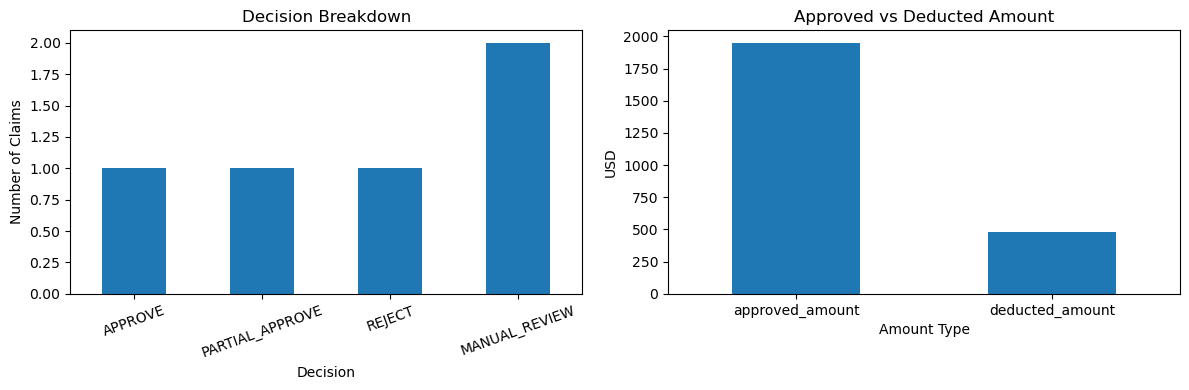

Dashboard totals:
Claims evaluated : 5
Total claimed    : $5,650.00
Total approved   : $1,950.00
Total deducted   : $480.00


In [9]:
results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

decision_counts = results_df["decision"].value_counts().reindex(
    ["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"], fill_value=0
)
decision_counts.plot(kind="bar", ax=axes[0], title="Decision Breakdown", rot=20)
axes[0].set_xlabel("Decision")
axes[0].set_ylabel("Number of Claims")

amounts = results_df[["approved_amount", "deducted_amount"]].sum()
amounts.plot(kind="bar", ax=axes[1], title="Approved vs Deducted Amount", rot=0)
axes[1].set_xlabel("Amount Type")
axes[1].set_ylabel("USD")

plt.tight_layout()
plt.show()

print("Dashboard totals:")
print(f"Claims evaluated : {len(results_df)}")
print(f"Total claimed    : ${claims_df['claimed_amount'].sum():,.2f}")
print(f"Total approved   : ${results_df['approved_amount'].sum():,.2f}")
print(f"Total deducted   : ${results_df['deducted_amount'].sum():,.2f}")


## 8. Design Notes & Reasoning

### Architecture
The prototype uses a **hybrid Agentic AI architecture**:

**Claim → Groq agent/tool selection → local policy tools → deterministic safety engine → schema validation → decision**

Groq is used for the agentic orchestration layer through the OpenAI-compatible client configuration. The model receives JSON-schema tool definitions and can request tools such as `policy_lookup`, `receipt_completeness_check`, `limit_checker`, `approval_threshold_check`, and `timeliness_check`. Python executes only allow-listed local functions and sends their results back to Groq for the next tool-selection step.

The final reimbursement decision is intentionally **not delegated to the LLM**. This prevents hallucinated arithmetic or policy interpretation from overriding hard reimbursement rules.

### Assumptions
1. The assignment provides a trip start/end but not a separate expense date for each line item. The latest trip date is used as the expense date for the 30-day check.
2. The provided descriptions such as “2 nights @ $250” and “3 days @ ~$60/day” are treated as authoritative structured metadata.
3. For Manual Review, `approved_amount` and `deducted_amount` are both `0.00` because the agent is explicitly not making a final reimbursement decision. The explanation preserves the known issue so a human can resolve it.
4. The assignment's “documented business purpose” condition is represented by the supplied business-purpose text. No external employee/company data is introduced.

### Why Groq + deterministic tools?
Groq provides the GenAI/Agentic behavior requested by the assignment: the model can select tools, receive tool results, and continue the workflow. The deterministic layer provides reliability:
- hard policy rules are stored with stable `POL-*` references;
- calculations are performed in Python;
- policy-critical Manual Review gates cannot be bypassed by the LLM;
- the final structure is validated before output.

This separation demonstrates practical **LLM orchestration + tool use + guardrails**, rather than an LLM-only classifier.

### Why Manual Review?
- **CLM-004:** business-class airfare is explicitly a policy exception; lodging also has a missing required receipt; the claim exceeds $2,000. These conditions require human handling.
- **CLM-005:** the meal claim is above $25 and has no receipt, so POL-RCT-02 requires Manual Review. The meal cap would also matter after the receipt issue is resolved.

### Trade-offs
- A structured policy dictionary is used instead of a vector database because the supplied policy is short and has stable rule IDs.
- Groq tool calling is used instead of adding a heavyweight agent framework, keeping the implementation easy to inspect.
- The deterministic safety layer means the solution remains runnable even if the API key is missing or the LLM call fails.

### What I would improve next
1. Add receipt/document OCR and receipt-to-claim reconciliation.
2. Add semantic policy retrieval for a larger policy library.
3. Add duplicate-claim detection using receipt hashes, vendor/date/amount similarity, and embeddings.
4. Add human-review queue integration and approval history.
5. Add evaluation datasets for tool-selection accuracy, policy-grounding accuracy, and decision consistency.
6. Add tracing/observability for prompts, tool calls, latency, token cost, and reviewer overrides.
7. Add authentication, PII masking, encryption, and access controls for real enterprise deployment.


## 9. Expected Decision Summary

The policy-driven outcomes for the supplied claims are:

- **CLM-001 → APPROVE**: $1,110.00 reimbursable and fully compliant.
- **CLM-002 → REJECT**: spa and minibar are ineligible; $380.00 deducted.
- **CLM-003 → PARTIAL_APPROVE**: lodging is capped at $200/night, so $100.00 is deducted; $840.00 approved.
- **CLM-004 → MANUAL_REVIEW**: business-class airfare exception, missing lodging receipt, and >$2,000 authority threshold.
- **CLM-005 → MANUAL_REVIEW**: required meal receipt is missing; human review is required rather than silently rejecting it.

These outcomes follow the supplied policy rather than an invented scoring rubric.


## 10. Final Structured Results


The final output is generated from the validated agent results; no LLM-generated field is allowed to change the deterministic policy decision.


In [10]:
# FINAL CODE CELL — do not add fields to these result objects.
final_results = [
    {
        "claim_id": r["claim_id"],
        "decision": r["decision"],
        "approved_amount": r["approved_amount"],
        "deducted_amount": r["deducted_amount"],
        "missing_docs": r["missing_docs"],
        "policy_refs": r["policy_refs"],
        "confidence": r["confidence"],
        "explanation": r["explanation"],
        "tools_used": r["tools_used"],
    }
    for r in results
]

print(json.dumps(final_results, indent=2))


[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-01",
      "POL-AIR-01",
      "POL-PD-02",
      "POL-PD-01",
      "POL-RCT-01",
      "POL-RCT-02",
      "POL-PD-03",
      "POL-APR-02",
      "POL-TIME-01"
    ],
    "confidence": 0.99,
    "explanation": "All claimed items are eligible, required receipts are present, no per-diem excess was detected, the claim is timely, and the reimbursable amount of $1110.00 is within an approvable tier (MANAGER).",
    "tools_used": [
      "policy_lookup",
      "receipt_completeness_check",
      "limit_checker",
      "timeliness_check",
      "approval_threshold_check"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02",
      "POL-RCT-01",
      "POL-RCT-02",
      "POL-PD-01"